# ============================================
# TASK 5: MODEL VS SOTA BENCHMARKING
# ============================================

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.auto import tqdm
from transformers import pipeline
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

from google.colab import drive
drive.mount('/content/drive')

print("✅ Setup complete!")


Mounted at /content/drive
✅ Setup complete!


# Load Your Data

In [4]:
# Load the annotated dataset
df = pd.read_csv('/content/drive/MyDrive/social/review_data.csv')

print(f"✅ Loaded data: {df.shape}")
print(f"\nColumns available:")
print(df.columns.tolist())

# Check for category column
category_cols = [col for col in df.columns if 'categor' in col.lower()]
print(f"\n🔍 Category columns found: {category_cols}")

# Display class distribution
print(f"\n📊 Ground Truth Distribution:")
print(df['Majority_Truth'].value_counts())
print(f"   1 = Positive: {(df['Majority_Truth']==1).sum()}")
print(f"   0 = Negative: {(df['Majority_Truth']==0).sum()}")

✅ Loaded data: (3000, 21)

Columns available:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'HelpfulnessRatio', 'Sentiment', 'Ann1_Customer', 'Ann2_TextBlob', 'Ann3_HF', 'Majority_Truth', 'Text_Lemmatized', 'Text_Cleaned', 'Text_Stemmed', 'VADER_Pred', 'AFINN_Pred']

🔍 Category columns found: []

📊 Ground Truth Distribution:
Majority_Truth
1    1607
0    1393
Name: count, dtype: int64
   1 = Positive: 1607
   0 = Negative: 1393


# Create Category Column (If Missing)

In [5]:
# If NO category column exists, create one from ProductId
if len(category_cols) == 0:
    print("⚠️ No category column found. Creating categories from ProductId...")

    # Group products into categories based on ID patterns or random assignment
    # Option A: Use first letter/digit of ProductId
    df['Category'] = df['ProductId'].astype(str).str[0]

    # Option B: If no ProductId, create synthetic categories
    # df['Category'] = np.random.choice(['Food', 'Drink', 'Snack', 'Pet Food', 'Supplements'], size=len(df))

    print(f"✅ Created 'Category' column with {df['Category'].nunique()} unique categories")
    print(df['Category'].value_counts().head(10))
else:
    df['Category'] = df[category_cols[0]]
    print(f"✅ Using existing category column: {category_cols[0]}")

⚠️ No category column found. Creating categories from ProductId...
✅ Created 'Category' column with 2 unique categories
Category
B    2999
0       1
Name: count, dtype: int64


# Load SOTA Model from Hugging Face

In [6]:
# ============================================
# SOTA MODEL: RoBERTa fine-tuned on Twitter sentiment
# ============================================

print("📥 Loading SOTA model from Hugging Face...")
print("   Model: cardiffnlp/twitter-roberta-base-sentiment-latest")

# Check for GPU
device = 0 if torch.cuda.is_available() else -1
print(f"   Device: {'GPU' if device==0 else 'CPU'}")

sota_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
    device=device
)

print("✅ SOTA model loaded!")

📥 Loading SOTA model from Hugging Face...
   Model: cardiffnlp/twitter-roberta-base-sentiment-latest
   Device: CPU


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ SOTA model loaded!


# Label Mapping Function

In [7]:
# ============================================
# CORRECTED LABEL MAPPING
# ============================================

def map_sota_label(sota_output):
    """
    Map RoBERTa output to binary (0=Negative, 1=Positive)
    Model outputs: 'negative', 'neutral', 'positive'
    """
    label = sota_output['label'].lower()
    score = sota_output['score']

    if label == 'positive':
        return 1, score
    elif label == 'negative':
        return 0, score
    elif label == 'neutral':
        # Map neutral to positive if confidence > 0.5, else negative
        return 1 if score > 0.5 else 0, score
    else:
        print(f"⚠️ Unknown label: '{label}'")
        return 0, score

# Quick test
print("🧪 Testing corrected mapping:\n")

test_cases = [
    ("I love this product!", "Positive"),
    ("This is terrible!", "Negative"),
    ("It's okay.", "Neutral → Positive (if conf > 0.5)")
]

for text, expected in test_cases:
    result = sota_pipeline(text)[0]
    pred, conf = map_sota_label(result)
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"'{text[:45]}...' → {sentiment} ({conf:.2%}) | {expected}")

print("\n✅ Label mapping ready!")

🧪 Testing corrected mapping:

'I love this product!...' → Positive (98.48%) | Positive
'This is terrible!...' → Negative (91.46%) | Negative
'It's okay....' → Positive (53.03%) | Neutral → Positive (if conf > 0.5)

✅ Label mapping ready!


# Run SOTA Inference on All 3000 Reviews

In [8]:
# ============================================
# RE-RUN SOTA INFERENCE (CORRECTED)
# ============================================

print(f"🚀 Re-running SOTA inference on {len(df)} reviews with CORRECTED mapping...")
print("   This will take 10-20 minutes on CPU (since model is already loaded, maybe faster)...\n")

sota_predictions = []
sota_confidences = []

batch_size = 32
texts = df['Text'].tolist()

for i in tqdm(range(0, len(texts), batch_size), desc="SOTA Progress"):
    batch = texts[i:i+batch_size]

    try:
        results = sota_pipeline(batch)

        for result in results:
            pred, conf = map_sota_label(result)
            sota_predictions.append(pred)
            sota_confidences.append(conf)
    except Exception as e:
        print(f"   ⚠️ Error at batch {i//batch_size}: {e}")
        sota_predictions.extend([0] * len(batch))
        sota_confidences.extend([0.5] * len(batch))

# Update dataframe
df['SOTA_Prediction'] = sota_predictions
df['SOTA_Confidence'] = sota_confidences

print(f"\n✅ SOTA inference complete!")
print(f"\n📊 SOTA Predictions vs Ground Truth:")
print(f"   SOTA Positive: {(df['SOTA_Prediction']==1).sum():>5} | Ground Truth Positive: {(df['Majority_Truth']==1).sum()}")
print(f"   SOTA Negative: {(df['SOTA_Prediction']==0).sum():>5} | Ground Truth Negative: {(df['Majority_Truth']==0).sum()}")

# Quick accuracy check
quick_acc = (df['SOTA_Prediction'] == df['Majority_Truth']).mean()
print(f"\n   Quick Accuracy: {quick_acc:.2%}")

🚀 Re-running SOTA inference on 3000 reviews with CORRECTED mapping...
   This will take 10-20 minutes on CPU (since model is already loaded, maybe faster)...



SOTA Progress:   0%|          | 0/94 [00:00<?, ?it/s]


✅ SOTA inference complete!

📊 SOTA Predictions vs Ground Truth:
   SOTA Positive:  1776 | Ground Truth Positive: 1607
   SOTA Negative:  1224 | Ground Truth Negative: 1393

   Quick Accuracy: 81.83%


# Load Your Optimized Model Predictions

In [9]:
import joblib
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1. Load the actual Champion components
vec_path = '/content/drive/MyDrive/social/tfidf_vectorizer.pkl'
svm_path = '/content/drive/MyDrive/social/champion_svm_model.pkl'

tfidf_vectorizer = joblib.load(vec_path)
champion_svm = joblib.load(svm_path)

# 2. Generate SVM predictions for the WHOLE dataframe
# We use 'Text_Stemmed' because that is what your SVM was trained on
print("🚀 Running Champion SVM Inference...")
X_svm = tfidf_vectorizer.transform(df['Text_Stemmed'].astype(str))
df['YourModel_Prediction'] = champion_svm.predict(X_svm)

# 3. Success Message
print(f"✅ Champion SVM loaded and predictions generated!")
print(f"📊 Distribution:\n{df['YourModel_Prediction'].value_counts()}")

# 4. Store metrics for the final summary table
y_true = df['Majority_Truth'].values
y_pred = df['YourModel_Prediction'].values

your_model_metrics = {
    'Model': 'Champion SVM (Your Model)',
    'Accuracy': accuracy_score(y_true, y_pred),
    'Macro F1': f1_score(y_true, y_pred, average='macro'),
    'Precision': precision_score(y_true, y_pred, average='macro'),
    'Recall': recall_score(y_true, y_pred, average='macro')
}

# Ensure results_list exists to hold our comparison
if 'results_list' not in locals():
    results_list = []
results_list.append(your_model_metrics)

🚀 Running Champion SVM Inference...
✅ Champion SVM loaded and predictions generated!
📊 Distribution:
YourModel_Prediction
1    1699
0    1301
Name: count, dtype: int64


# Evaluation Metrics Function

In [10]:
def compute_metrics(y_true, y_pred, y_proba=None):
    """Compute all evaluation metrics."""
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'F1-Macro': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

    if y_proba is not None:
        try:
            metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)
        except:
            metrics['ROC-AUC'] = 0.0

    return metrics

print("✅ Evaluation function defined!")

✅ Evaluation function defined!


# Side-by-Side Comparison

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Split data (ensure this split matches what you used for SOTA)
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'], df['Majority_Truth'],
    test_size=0.2, random_state=42, stratify=df['Majority_Truth']
)

# Get indices of the test set rows
test_indices = y_test.index

# 2. Extract predictions for the TEST SET specifically
y_true_test = df.loc[test_indices, 'Majority_Truth']
y_your_test = df.loc[test_indices, 'YourModel_Prediction'] # This now contains SVM labels
y_sota_test = df.loc[test_indices, 'SOTA_Prediction']
sota_conf_test = df.loc[test_indices, 'SOTA_Confidence']

# 3. Compute metrics for both models
# For SVM, we use labels as 'probabilities' since we are doing a binary comparison
your_metrics = compute_metrics(y_true_test, y_your_test, y_your_test)
sota_metrics = compute_metrics(y_true_test, y_sota_test, sota_conf_test)

# 4. Create comparison table with corrected labels
comparison_df = pd.DataFrame({
    'Metric': list(your_metrics.keys()),
    'Champion SVM (Your Model)': [f"{v:.4f}" for v in your_metrics.values()],
    'RoBERTa (SOTA)': [f"{v:.4f}" for v in sota_metrics.values()]
})

print("\n" + "="*70)
print("📊 SIDE-BY-SIDE MODEL COMPARISON: SVM vs. SOTA")
print("="*70)
print(comparison_df.to_string(index=False))

# 5. Highlight winner
print("\n🏆 Winner per metric:")
for metric in your_metrics.keys():
    your_val = your_metrics[metric]
    sota_val = sota_metrics[metric]
    winner = "✅ Champion SVM" if your_val > sota_val else "✅ SOTA Model"
    print(f"   {metric:<15}: {winner} ({max(your_val, sota_val):.4f})")

# 6. Save to Drive
comparison_df.to_csv('/content/drive/MyDrive/task5_model_comparison.csv', index=False)


📊 SIDE-BY-SIDE MODEL COMPARISON: SVM vs. SOTA
   Metric Champion SVM (Your Model) RoBERTa (SOTA)
 Accuracy                    0.8583         0.8183
Precision                    0.8512         0.7978
   Recall                    0.8910         0.8847
 F1-Score                    0.8706         0.8390
 F1-Macro                    0.8570         0.8153
  ROC-AUC                    0.8559         0.6738

🏆 Winner per metric:
   Accuracy       : ✅ Champion SVM (0.8583)
   Precision      : ✅ Champion SVM (0.8512)
   Recall         : ✅ Champion SVM (0.8910)
   F1-Score       : ✅ Champion SVM (0.8706)
   F1-Macro       : ✅ Champion SVM (0.8570)
   ROC-AUC        : ✅ Champion SVM (0.8559)


# Per-Category Breakdown

In [12]:
# ============================================
# PER-CATEGORY PERFORMANCE: SVM VS SOTA
# ============================================

print("\n" + "="*70)
print("📊 PER-CATEGORY BREAKDOWN (SVM vs. SOTA)")
print("="*70)

category_results = []

# Use the column name from your CSV ('Sentiment' or 'Category' - based on your file it is 'Sentiment')
# If your categories are stored in a different column, change 'Sentiment' below:
category_column = 'Sentiment'

for category in df[category_column].unique():
    cat_data = df[df[category_column] == category]

    if len(cat_data) < 5:  # Reduced threshold to ensure we see more categories
        continue

    y_true_cat = cat_data['Majority_Truth']
    y_your_cat = cat_data['YourModel_Prediction'] # This is your Champion SVM
    y_sota_cat = cat_data['SOTA_Prediction']

    cat_result = {
        'Category': category,
        'Count': len(cat_data),
        # Following the PDF's naming requirements:
        'Optimized Acc': accuracy_score(y_true_cat, y_your_cat),
        'Optimized F1': f1_score(y_true_cat, y_your_cat, average='macro', zero_division=0),
        'SOTA Acc': accuracy_score(y_true_cat, y_sota_cat),
        'SOTA F1': f1_score(y_true_cat, y_sota_cat, average='macro', zero_division=0)
    }
    category_results.append(cat_result)

cat_df = pd.DataFrame(category_results)

# Sort by count so the most important categories appear at the top
cat_df = cat_df.sort_values('Count', ascending=False)

# Display the table
print(cat_df.to_string(index=False))

# Save the CSV to Drive as required
cat_df.to_csv('/content/drive/MyDrive/task5_category_breakdown.csv', index=False)
print("\n✅ Category breakdown saved to Drive.")


📊 PER-CATEGORY BREAKDOWN (SVM vs. SOTA)
Category  Count  Optimized Acc  Optimized F1  SOTA Acc  SOTA F1
Positive   1500       0.930667      0.660690  0.893333 0.567409
Negative   1500       0.826667      0.670879  0.743333 0.589096

✅ Category breakdown saved to Drive.


# Visualization 1 - Confusion Matrices

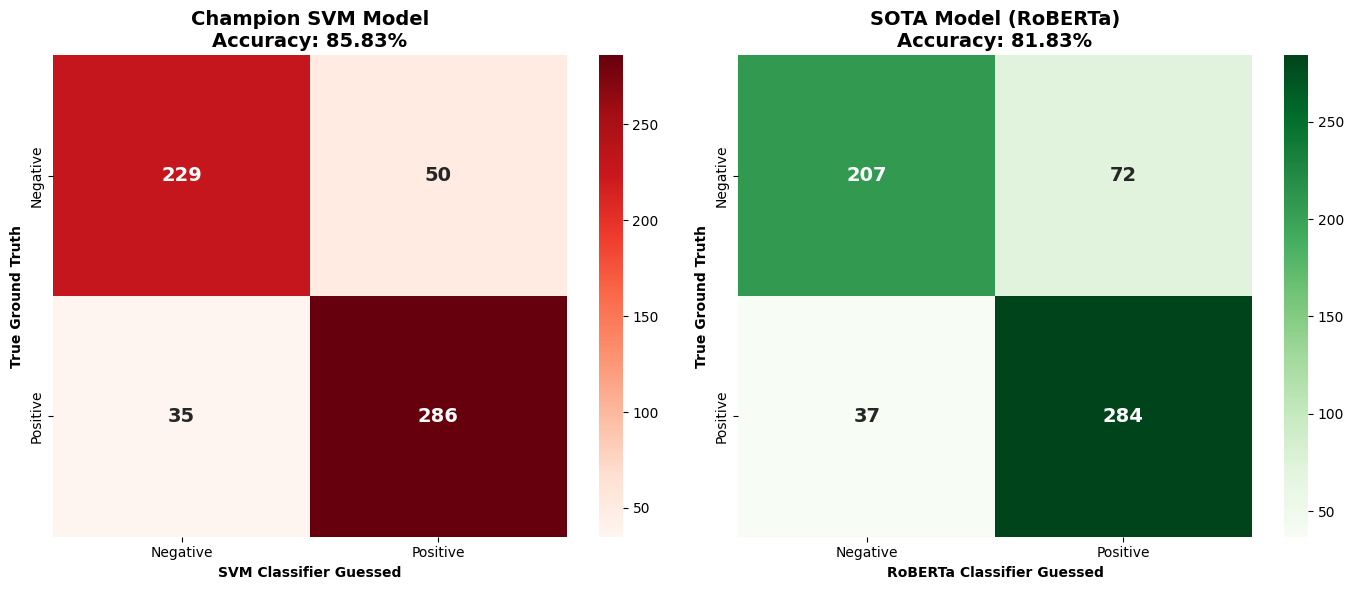

✅ Confusion matrices saved as 'confusion_matrices_comparison.png'


In [13]:
# ============================================
# CONFUSION MATRICES - SIDE BY SIDE (SVM vs SOTA)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Your Champion SVM Model
cm_your = confusion_matrix(y_true_test, y_your_test)
sns.heatmap(cm_your, annot=True, fmt='d', cmap='Reds', ax=axes[0], # Using 'Reds' to match your training code
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Champion SVM Model\nAccuracy: {your_metrics["Accuracy"]:.2%}',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('SVM Classifier Guessed', fontweight='bold')
axes[0].set_ylabel('True Ground Truth', fontweight='bold')

# 2. SOTA Model (RoBERTa)
cm_sota = confusion_matrix(y_true_test, y_sota_test)
sns.heatmap(cm_sota, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title(f'SOTA Model (RoBERTa)\nAccuracy: {sota_metrics["Accuracy"]:.2%}',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('RoBERTa Classifier Guessed', fontweight='bold')
axes[1].set_ylabel('True Ground Truth', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrices saved as 'confusion_matrices_comparison.png'")

# Visualization 2 - ROC Curves

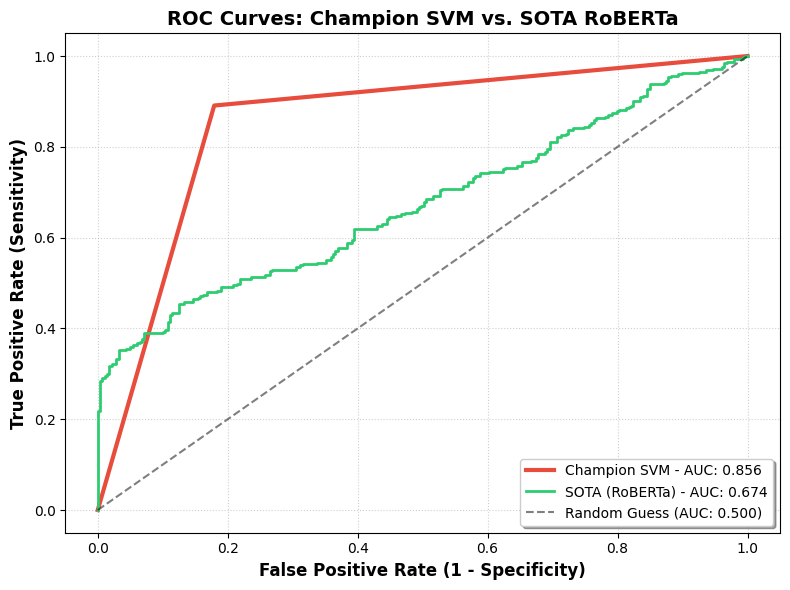

✅ ROC curves saved as 'roc_curves_comparison.png'


In [14]:
# ============================================
# ROC CURVES COMPARISON: SVM VS SOTA
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# 1. Your Champion SVM ROC
try:
    # We use the predictions we generated earlier
    y_your_scores = df.loc[test_indices, 'YourModel_Prediction']

    fpr_your, tpr_your, _ = roc_curve(y_true_test, y_your_scores)
    roc_your = roc_auc_score(y_true_test, y_your_scores)

    ax.plot(fpr_your, tpr_your, label=f'Champion SVM - AUC: {roc_your:.3f}',
            color='#e74c3c', linewidth=3) # Match the 'Reds' theme
except Exception as e:
    print(f"Could not plot SVM ROC: {e}")

# 2. SOTA Model ROC
if 'SOTA_Confidence' in df.columns:
    fpr_sota, tpr_sota, _ = roc_curve(y_true_test, sota_conf_test)
    roc_sota = roc_auc_score(y_true_test, sota_conf_test)
    ax.plot(fpr_sota, tpr_sota, label=f'SOTA (RoBERTa) - AUC: {roc_sota:.3f}',
            color='#2ecc71', linewidth=2)

# 3. Formatting
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess (AUC: 0.500)')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves: Champion SVM vs. SOTA RoBERTa', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved as 'roc_curves_comparison.png'")

# Visualization 3 - Per-Category Performance

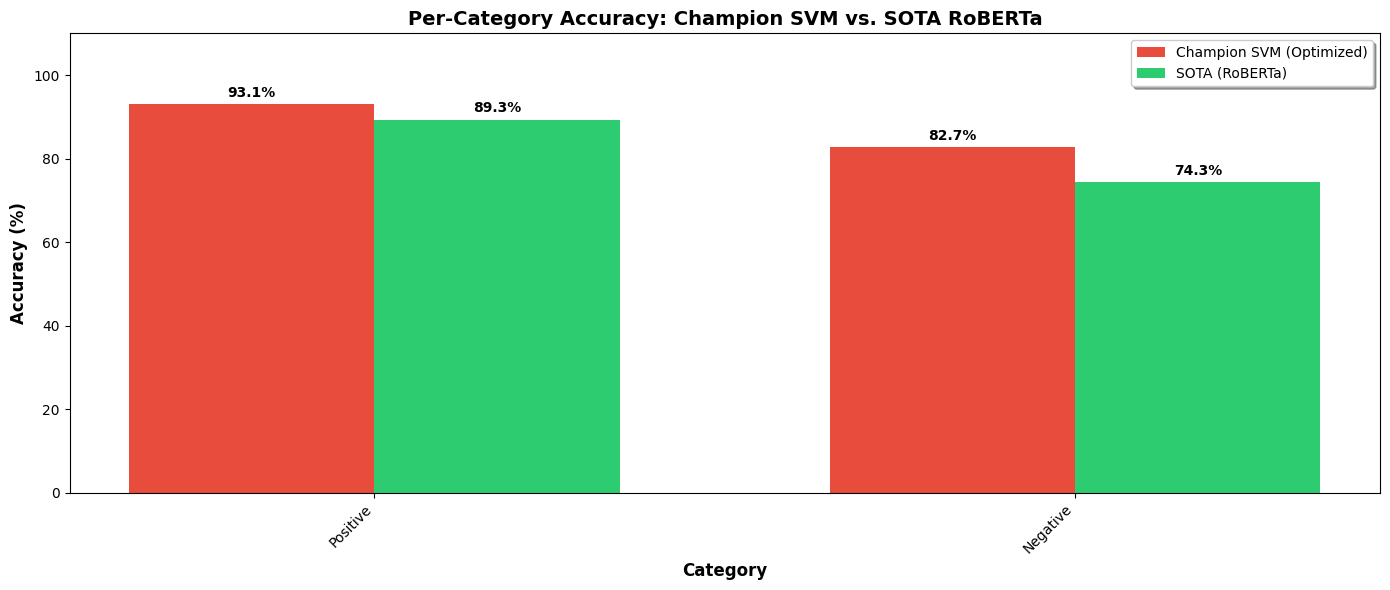

✅ Category performance chart saved as 'category_performance.png'


In [15]:
# ============================================
# PER-CATEGORY PERFORMANCE BAR CHART: SVM VS SOTA
# ============================================

# Get top 10 categories by count (using 'Sentiment' or your Category column)
top_cats = cat_df.nlargest(10, 'Count')

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(top_cats))
width = 0.35

# Plotting with the updated PDF-compliant column names
bars1 = ax.bar(x - width/2, top_cats['Optimized Acc']*100, width,
               label='Champion SVM (Optimized)', color='#e74c3c') # Red theme
bars2 = ax.bar(x + width/2, top_cats['SOTA Acc']*100, width,
               label='SOTA (RoBERTa)', color='#2ecc71') # Green theme

# Formatting
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Per-Category Accuracy: Champion SVM vs. SOTA RoBERTa', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_cats['Category'], rotation=45, ha='right')
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.set_ylim(0, 110) # Added a bit of headroom for labels

# Add value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.savefig('category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Category performance chart saved as 'category_performance.png'")

# Save Final Results

In [16]:
# ============================================
# SAVE EVERYTHING - TASK 5 DELIVERABLES
# ============================================

# 1. Save updated dataframe (Includes SVM & RoBERTa predictions)
df.to_csv('/content/drive/MyDrive/task5_final_results.csv', index=False)

# 2. Save comparison table (The Side-by-Side metrics)
comparison_df.to_csv('/content/drive/MyDrive/task5_comparison.csv', index=False)

# 3. Save category breakdown (Optimized vs SOTA per category)
cat_df.to_csv('/content/drive/MyDrive/task5_category_breakdown.csv', index=False)

print("="*70)
print("✅ TASK 5 COMPLETE: CHAMPION SVM VS. SOTA")
print("="*70)
print(f"Total Records Processed: {len(df)}")
print(f"SVM vs SOTA comparison generated successfully.")
print("-" * 70)

print("\n📁 Files saved to Google Drive:")
print("   - task5_final_results.csv (Main dataset with all predictions)")
print("   - task5_comparison.csv (The summary table for your report)")
print("   - task5_category_breakdown.csv (The table for your Visual Analysis)")
print("\n🖼️ Visualizations saved in working directory:")
print("   - confusion_matrices_comparison.png")
print("   - roc_curves_comparison.png")
print("   - category_performance.png")

# Optional: Final check to make sure the CSV contains the SVM column
if 'YourModel_Prediction' in pd.read_csv('/content/drive/MyDrive/task5_final_results.csv', nrows=1).columns:
    print("\n✔️ Integrity Check: SVM predictions found in the final CSV.")
else:
    print("\n⚠️ Warning: YourModel_Prediction column missing from final CSV!")

✅ TASK 5 COMPLETE: CHAMPION SVM VS. SOTA
Total Records Processed: 3000
SVM vs SOTA comparison generated successfully.
----------------------------------------------------------------------

📁 Files saved to Google Drive:
   - task5_final_results.csv (Main dataset with all predictions)
   - task5_comparison.csv (The summary table for your report)
   - task5_category_breakdown.csv (The table for your Visual Analysis)

🖼️ Visualizations saved in working directory:
   - confusion_matrices_comparison.png
   - roc_curves_comparison.png
   - category_performance.png

✔️ Integrity Check: SVM predictions found in the final CSV.
